# Análise Exploratória de Dados — Steam (Dataset V2)
### TCC — Análise Preditiva da Popularidade de Jogos na Steam Utilizando Redes Neurais

**Discente:** Davi Augusto Farinela da Silva
**Orientador:** Prof. Dr. João Henrique Ferreira Flores

---

Esse é um EDA novo em cima da base V2 (`data/steam-jogos-v2.csv`). Antes de entrar nos gráficos eu preciso contar duas coisas que descobri revisando o pipeline essa semana, porque as duas mudam um pouco o que eu vou escrever na metodologia do TCC.

A primeira já era conhecida: a coleta original (V1, que é o que está descrito na Seção 3.1 do TCC hoje) tinha 86,7% de `reviews_total` faltante, e isso não era porque os jogos não tinham avaliação — era porque eu estava lendo o campo `recommendations.total` do `appdetails`, que a Steam simplesmente não retorna abaixo de um limiar de reviews que eles não documentam. A versão V2 da coleta resolve isso usando o endpoint `/appreviews` em vez disso (fica salvo no campo `exact_reviews`), e aí sim a cobertura fica praticamente completa (só 0,3% dos apps ficam sem esse dado).

A segunda eu só percebi agora, ao reconferir a coleta do zero pra ter certeza de que estava tudo certo antes de montar esse notebook: **a nossa base nunca teve DLC, soundtrack ou software — só jogos, tanto na V1 quanto na V2.** Isso não é um filtro que eu apliquei de propósito; é um comportamento padrão do endpoint que uso pra listar os app IDs (`IStoreService/GetAppList`), que segundo a própria documentação da Steamworks só retorna itens do tipo "Game" quando os parâmetros `include_dlc`/`include_software`/etc. não são passados — e eu nunca passei. Confirmei isso abrindo os dois checkpoints: 171.766 dos 171.769 apps do V2 (99,998%) são `type == "game"`, e o mesmo vale pro V1 (159.827 de 159.828). Pra um estudo de popularidade de jogos isso não chega a ser um problema — na prática é o escopo que eu quero mesmo — mas a documentação interna do repositório e o script de limpeza diziam que `steam-dados-v2.csv` "inclui DLCs, soundtracks etc.", o que é falso: os dois CSVs saem idênticos porque não sobra nada pra diferenciar. Já corrigi esses comentários.

De quebra, notei que o script de limpeza (`scripts/steam-analise-v2.py`) tinha sido movido de lugar numa reorganização de pastas e ficou apontando pro caminho errado dos checkpoints — rodando ele do jeito que estava ele quebrava com erro de arquivo não encontrado. Corrigi o caminho e rodei de novo do zero; o dataset final ficou com **118.596 jogos**, um pouco diferente dos 118.537 que estavam no CSV antigo (a diferença é pequena e não muda nenhuma conclusão, mas prefiro trabalhar em cima do dado gerado de forma reproduzível do que de um CSV que eu não consigo mais regenerar).

Com isso resolvido, o resto desse notebook é o EDA "de verdade" em cima do dataset de jogos.

**Atualização:** depois de mandar a primeira versão desse notebook, o professor voltou com uma rodada de comentários, e essa versão incorpora eles. Especificamente: aprofundei a análise de cartas colecionáveis (seção de Categorias), refiz a comparação de gênero em cima de proporção em vez de média — e, o ponto mais importante, parei de tratar Indie como só mais um gênero e passei a usar ele como corte "mestre" antes de olhar os outros gêneros, já que ele se sobrepõe a 59-78% de cada um dos demais. A parte de expectativa de ganhos (review x multiplicador) já tinha saído antes dessa rodada, e o professor confirmou que concorda em manter fora — segue assim, só reviews mesmo, que pelo menos é dado verificável. Sobre a análise de plataforma com dado do ProtonDB: cheguei a testar a viabilidade (dá pra puxar via API não-documentada do site), mas seriam ~118 mil consultas novas — mais de um dia de coleta rodando — e decidi que não vale o tempo nessa etapa do trabalho. Deixei uma ressalva no texto explicando a limitação em vez de fazer a coleta.

## 1. Carregamento e Configuração

Uso `data/steam-jogos-v2.csv` (jogos apenas, `type == "game"` — que hoje é sinônimo de "todos os apps coletados", pelo motivo explicado acima).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# Paleta (mesma paleta usada no resto do projeto — ver dataviz skill)
BLUE    = "#2a78d6"
ORANGE  = "#eb6834"
AQUA    = "#1baf7a"
YELLOW  = "#eda100"
RED     = "#e34948"
GREEN   = "#008300"
VIOLET  = "#4a3aa7"
INK     = "#0b0b0b"
INK_2   = "#52514e"
MUTED   = "#898781"
GRID    = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "axes.edgecolor":   MUTED,
    "axes.labelcolor":  INK_2,
    "text.color":       INK,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "grid.color":       GRID,
    "font.size":        10,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

df = pd.read_csv("data/steam-jogos-v2.csv", encoding="utf-8-sig", low_memory=False)
df["log_reviews"] = np.log1p(df["reviews_total"])
print(f"Dataset carregado: {df.shape[0]:,} jogos x {df.shape[1]} colunas")

Dataset carregado: 118,596 jogos x 52 colunas


## Visão Geral do Dataset

In [2]:
print(df.dtypes.value_counts())
print()
cols_amostra = ["appid", "name", "is_free", "price_brl", "reviews_total",
                 "review_score_desc", "release_year", "windows"]
df[cols_amostra].head(5)

bool       32
float64    12
int64       4
str         4
Name: count, dtype: int64



,appid,name,is_free,price_brl,reviews_total,review_score_desc,release_year,windows
0,2621440,Infinity Castle Dungeon,False,13.79,32.0,Positive,2024.0,True
1,1048580,Terje Haakonsen's Powder VR,False,37.99,56.0,Mixed,2020.0,True
2,2097160,Monster Mystery,True,0.00,0.0,No user reviews,2022.0,True
3,10,Counter-Strike,False,20.69,168343.0,Overwhelmingly Positive,2000.0,True
4,3145740,VRider SBK™,False,59.62,18.0,Mixed,2025.0,True


## Completude dos Dados

Já adianto: depois da curadoria (que trato em detalhe mais abaixo, quando falo da variável-alvo), a base final não tem praticamente nenhum dado faltante — porque as regras de limpeza já tratam isso (imputação com 0 onde faz sentido de negócio, remoção onde não faz). A única exceção grande é `metacritic_score`.

                           Faltantes  % Total
metacritic_score              114517    96.56
reviews_total                      0     0.00
reviews_positive                   0     0.00
achievements_total                 0     0.00
reviews_negative                   0     0.00
price_brl                          0     0.00
required_age                       0     0.00
review_score_desc                  0     0.00
supported_languages_count          0     0.00


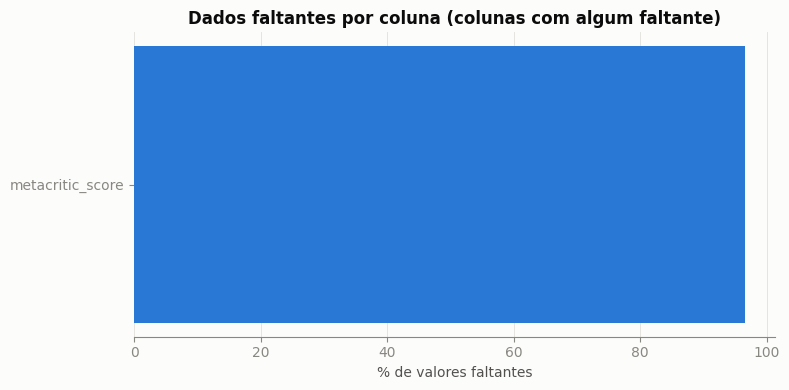

In [3]:
cols_check = ["reviews_total", "reviews_positive", "reviews_negative",
              "achievements_total", "price_brl", "required_age",
              "metacritic_score", "review_score_desc", "supported_languages_count"]
missing = df[cols_check].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"Faltantes": missing, "% Total": missing_pct}).sort_values("% Total", ascending=False)
print(miss_df)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = miss_df[miss_df["% Total"] > 0]
ax.barh(plot_df.index, plot_df["% Total"], color=BLUE, height=0.6)
ax.set_xlabel("% de valores faltantes")
ax.set_title("Dados faltantes por coluna (colunas com algum faltante)")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ["left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

`metacritic_score` falta em cerca de 96,6% dos jogos — é a nota do Metacritic, e a Steam só expõe esse campo pros jogos que o Metacritic realmente avaliou (a maioria indie nunca chega a ser avaliada por eles). Por causa desse volume de missing e do viés de seleção óbvio que ele carrega (jogos avaliados pelo Metacritic tendem a ser os "grandes"), decidi excluir essa coluna de qualquer modelo — já tinha registrado essa decisão antes e mantenho aqui.

## Variável-Alvo: Popularidade (`reviews_total`)

Uso `reviews_total` como proxy de popularidade, já que a Steam não expõe número de jogadores/downloads publicamente. A distribuição é extremamente assimétrica à direita (poucos jogos com milhões de reviews, a maioria com pouquíssimas), então trabalho com `log1p(reviews_total)` na maior parte das análises daqui pra frente — é a mesma decisão que já vinha do EDA anterior, e continua fazendo sentido aqui.

count    1.185960e+05
mean     9.266216e+02
std      2.089603e+04
min      0.000000e+00
25%      1.000000e+00
50%      8.000000e+00
75%      4.800000e+01
max      5.136950e+06
Name: reviews_total, dtype: float64

Jogos com 0 reviews: 20.6%


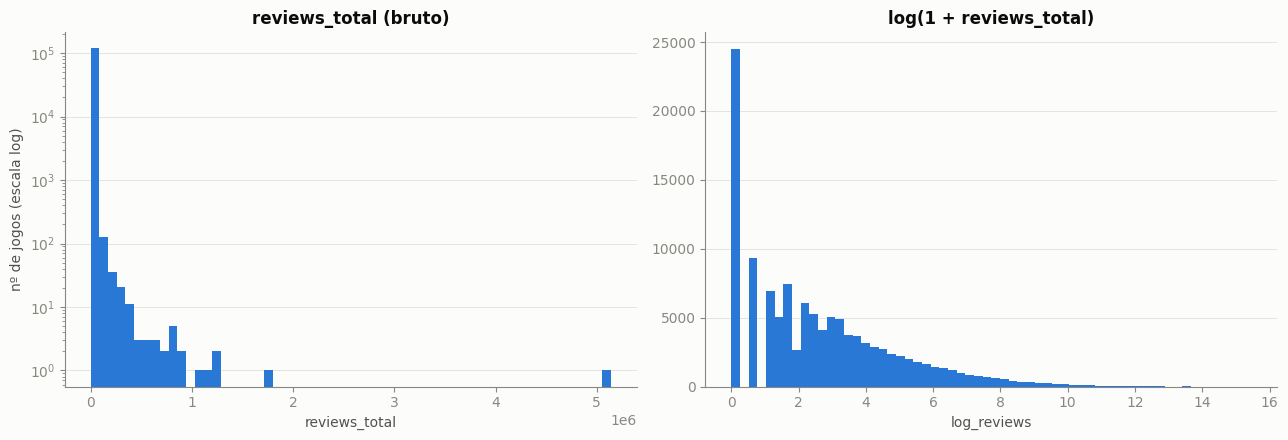

In [4]:
print(df["reviews_total"].describe())
print(f"\nJogos com 0 reviews: {(df['reviews_total']==0).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["reviews_total"], bins=60, color=BLUE)
axes[0].set_title("reviews_total (bruto)")
axes[0].set_yscale("log")
axes[0].set_xlabel("reviews_total")
axes[0].set_ylabel("nº de jogos (escala log)")
axes[0].grid(axis="y", linewidth=0.6)
axes[0].set_axisbelow(True)

axes[1].hist(df["log_reviews"], bins=60, color=BLUE)
axes[1].set_title("log(1 + reviews_total)")
axes[1].set_xlabel("log_reviews")
axes[1].grid(axis="y", linewidth=0.6)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

### Top 20 Jogos Mais Avaliados

Serve pra entender o "teto" da variável — quem está lá em cima e se os números fazem sentido (sanity check antes de confiar no resto da análise).

In [5]:
top20 = df.nlargest(20, "reviews_total")[["name", "reviews_total", "review_score_desc"]]
top20

,name,reviews_total,review_score_desc
174,Counter-Strike 2,5136950.0,Very Positive
12737,PUBG: BATTLEGROUNDS,1760712.0,Mixed
80454,Tom Clancy's Rainbow Six Siege,1244793.0,Very Positive
24082,Terraria,1219087.0,Overwhelmingly Positive
56047,Rust,1145371.0,Very Positive
1030,Garry's Mod,1073628.0,Overwhelmingly Positive
58118,Black Myth: Wukong,873856.0,Overwhelmingly Positive
88569,Stardew Valley,872364.0,Overwhelmingly Positive
10219,Cyberpunk 2077,850482.0,Very Positive
7188,HELLDIVERS™ 2,828665.0,Mostly Positive


Bate com o que eu esperaria olhar de fora: Counter-Strike 2 na frente disparado (mais de 5 milhões de reviews — faz sentido, é F2P e é o jogo competitivo mais jogado da Steam), seguido de PUBG, Rainbow Six Siege, Terraria, Rust, Garry's Mod. Nenhum nome estranho na lista, o que me dá alguma confiança de que a coleta e a limpeza não bagunçaram os dados nesse extremo.

### Categorização da Popularidade

Divido em faixas pra facilitar leitura (e como possível alternativa de target multiclasse, discuto isso na síntese lá embaixo).

                            n     %
pop_cat                            
Sem Avaliações (0)      24479  20.6
Pouco Avaliado (1-9)    37473  31.6
Avaliado (10-99)        35125  29.6
Bem Avaliado (100-999)  15054  12.7
Muito Avaliado (1000+)   6465   5.5


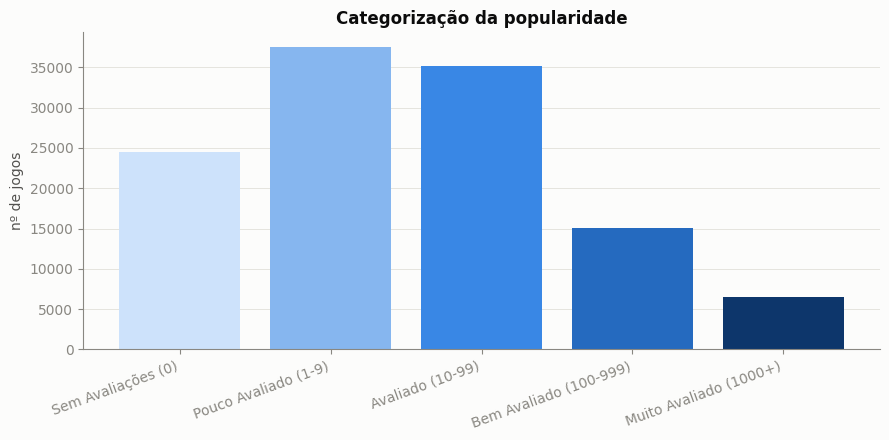

In [6]:
bins   = [-1, 0, 9, 99, 999, float("inf")]
labels = ["Sem Avaliações (0)", "Pouco Avaliado (1-9)", "Avaliado (10-99)",
          "Bem Avaliado (100-999)", "Muito Avaliado (1000+)"]
df["pop_cat"] = pd.cut(df["reviews_total"], bins=bins, labels=labels)

cont = df["pop_cat"].value_counts().reindex(labels)
pct  = (cont / len(df) * 100).round(1)
print(pd.DataFrame({"n": cont, "%": pct}))

fig, ax = plt.subplots(figsize=(9, 4.5))
# ramp sequencial (mesma familia azul), do mais claro (baixa popularidade) ao mais escuro
ramp = ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#0d366b"]
ax.bar(labels, cont.values, color=ramp)
ax.set_ylabel("nº de jogos")
ax.set_title("Categorização da popularidade")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

20,6% dos jogos não têm avaliação nenhuma, e mais de 50% têm menos de 10. É um retrato bem desigual — a maioria dos jogos publicados na Steam praticamente não é notada, e um punhado concentra a atenção. Dado esse formato de cauda longa, acho que **classificação multiclasse** (usando essas faixas, ou algo parecido) é uma alternativa que vale a pena considerar ao lado da regressão pura sobre `log_reviews` — os limiares acima são só uma primeira proposta, baseada na distribuição empírica, não tenho ainda uma justificativa teórica mais forte pra eles.

## Análise Univariada das Variáveis Numéricas

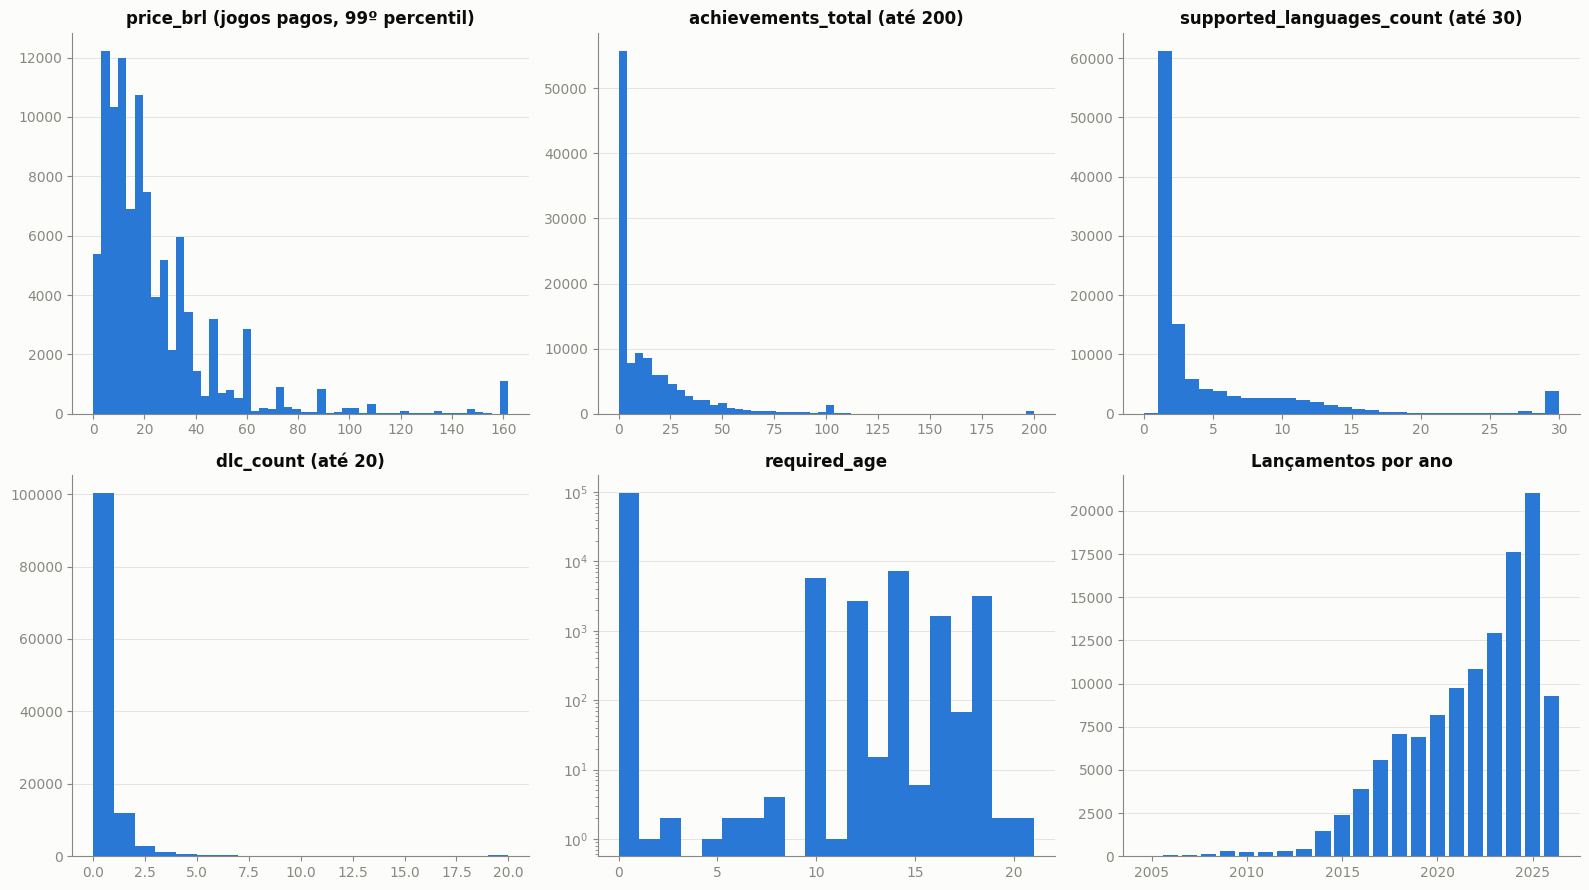

price_brl: media=175.58, mediana=13.79, max=585000.00
achievements_total: media=19.32, mediana=6.00, max=9821.00
supported_languages_count: media=5.79, mediana=1.00, max=103.00
dlc_count: media=0.50, mediana=0.00, max=3782.00


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

price_paid = df.loc[~df["is_free"], "price_brl"]
axes[0, 0].hist(price_paid.clip(upper=price_paid.quantile(0.99)), bins=50, color=BLUE)
axes[0, 0].set_title("price_brl (jogos pagos, 99º percentil)")

axes[0, 1].hist(df["achievements_total"].clip(upper=200), bins=50, color=BLUE)
axes[0, 1].set_title("achievements_total (até 200)")

axes[0, 2].hist(df["supported_languages_count"].clip(upper=30), bins=30, color=BLUE)
axes[0, 2].set_title("supported_languages_count (até 30)")

axes[1, 0].hist(df["dlc_count"].clip(upper=20), bins=20, color=BLUE)
axes[1, 0].set_title("dlc_count (até 20)")

axes[1, 1].hist(df["required_age"], bins=20, color=BLUE)
axes[1, 1].set_title("required_age")
axes[1, 1].set_yscale("log")

year_counts = df[df["release_year"].between(2005, 2026)]["release_year"].value_counts().sort_index()
axes[1, 2].bar(year_counts.index, year_counts.values, color=BLUE)
axes[1, 2].set_title("Lançamentos por ano")

for ax in axes.flat:
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

for col in ["price_brl", "achievements_total", "supported_languages_count", "dlc_count"]:
    print(f"{col}: media={df[col].mean():.2f}, mediana={df[col].median():.2f}, max={df[col].max():.2f}")

Alguns pontos que valem nota, porque achei esquisitos ao olhar de perto:

- **`price_brl` tem outliers que parecem erro de dado, não jogo caro de verdade.** Tem 189 jogos listados acima de R\$1.000 — e alguns deles (Atomic Heart a R\$549.000, HOT WHEELS UNLEASHED a R\$579.000) claramente não custam isso na loja de verdade. Não investiguei a fundo ainda de onde vem esse erro (suspeito de conversão de moeda ou algum campo de bundle sendo lido errado pelo `price_overview`), mas pra modelagem provavelmente vale a pena tratar isso (capar no percentil ou investigar caso a caso) antes de usar `price_brl` como feature — do jeito que está, esses poucos valores absurdos vão dominar qualquer normalização.
- **`achievements_total` também tem um outlier gigante, mas esse é real:** LOGistICAL tem 9.821 conquistas cadastradas. É um caso conhecido — tem uma família de jogos (LOGistICAL, "achievement farms") feitos especificamente com uma quantidade absurda de conquistas. Não é erro de coleta, é assim mesmo.
- **`dlc_count` também tem outliers legítimos:** Fantasy Grounds VTT aparece com 3.782 DLCs, e vários simuladores de trem (Trainz Railroad Simulator, Trainz Plus) também têm centenas — esses jogos realmente vendem conteúdo em um modelo de "centenas de pacotes pagos", então também não acho que seja erro.

Ou seja: preciso tratar os outliers de preço antes de modelar, mas os de conquistas e DLC parecem genuínos e talvez só peçam um `clip` ou padronização mais robusta (ex: RobustScaler) em vez de remoção.

## Análise de Gêneros

### Frequência de Gêneros

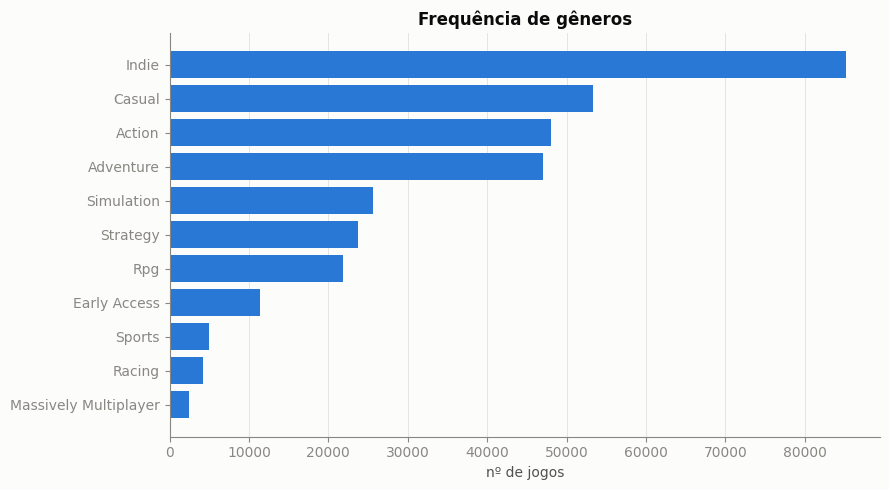

,n,%
Indie,85231,71.9
Casual,53377,45.0
Action,48000,40.5
Adventure,47047,39.7
Simulation,25662,21.6
Strategy,23717,20.0
Rpg,21879,18.4
Early Access,11330,9.6
Sports,5024,4.2
Racing,4246,3.6


In [8]:
genre_cols = [c for c in df.columns if c.startswith("genre_")]
genre_counts = df[genre_cols].sum().sort_values(ascending=False)
genre_counts.index = genre_counts.index.str.replace("genre_", "").str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=BLUE)
ax.set_xlabel("nº de jogos")
ax.set_title("Frequência de gêneros")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

genre_pct = (genre_counts / len(df) * 100).round(1)
pd.DataFrame({"n": genre_counts.astype(int), "%": genre_pct})

### Interseção entre Gêneros

O professor chamou atenção pra um problema real: essas colunas de gênero não são mutuamente excludentes, e eu estava tratando cada uma isoladamente (com/sem aquele gênero) sem olhar quanto elas se sobrepõem. Um jogo pode perfeitamente ser Action, Adventure e Indie ao mesmo tempo. Antes de mexer em qualquer análise, calculei a sobreposição de verdade em vez de supor.

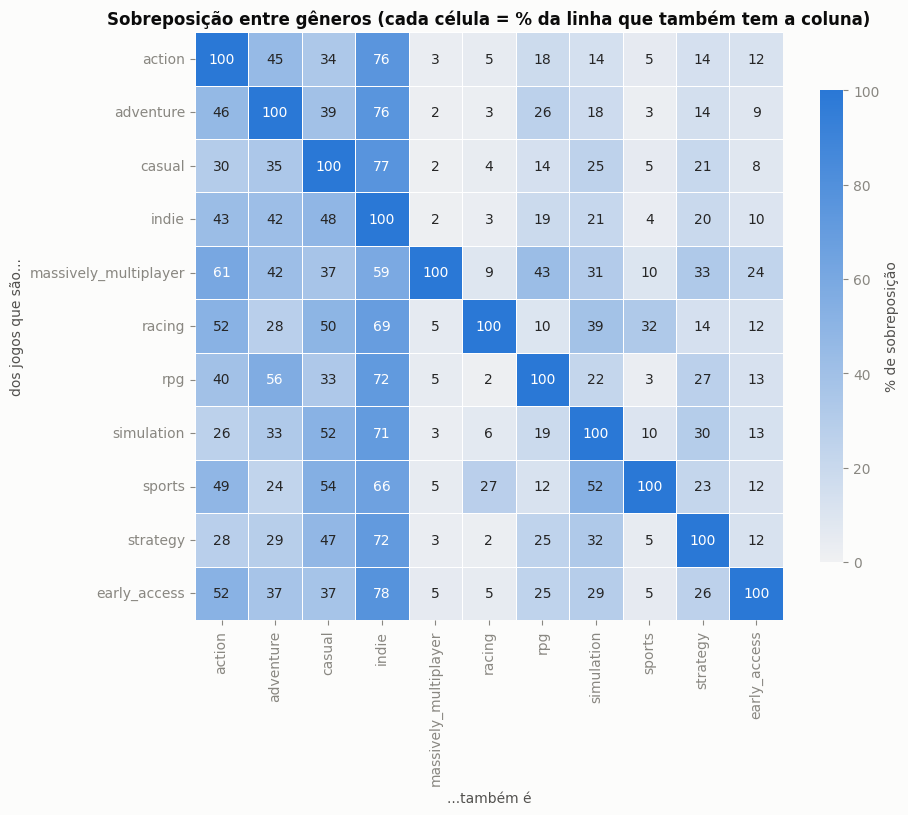

In [9]:
genre_names = [c.replace("genre_", "") for c in genre_cols]
overlap = pd.DataFrame(index=genre_names, columns=genre_names, dtype=float)
for c1 in genre_cols:
    base = df[c1].sum()
    for c2 in genre_cols:
        overlap.loc[c1.replace("genre_", ""), c2.replace("genre_", "")] = (df[c1] & df[c2]).sum() / base * 100

fig, ax = plt.subplots(figsize=(9.5, 8))
cmap = sns.light_palette(BLUE, as_cmap=True)
sns.heatmap(overlap, annot=True, fmt=".0f", cmap=cmap, vmin=0, vmax=100,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "% de sobreposição"}, ax=ax)
ax.set_xlabel("...também é")
ax.set_ylabel("dos jogos que são...")
ax.set_title("Sobreposição entre gêneros (cada célula = % da linha que também tem a coluna)")
plt.tight_layout()
plt.show()

Dá pra ver na linha/coluna do Indie que o problema é sistêmico, não pontual: **entre 59% (Massively Multiplayer) e 78% (Early Access) de cada um dos outros gêneros também carrega o rótulo Indie.** Ou seja, mais de metade de qualquer gênero que eu escolher é, ao mesmo tempo, Indie. Isso confirma o que o professor suspeitava: Indie não funciona como um gênero de conteúdo (tipo RPG ou Strategy, que descrevem o que o jogo é) — funciona muito mais como um rótulo de "modelo de publicação" (autopublicado, sem uma editora grande por trás), que atravessa praticamente todo o catálogo. Faz sentido, então, parar de tratar Indie como só mais uma linha nas comparações de gênero e usar ele como o primeiro corte, exatamente como o professor sugeriu.

### Indie como Categoria Mestre

Daqui pra frente, separo primeiro por Indie / Não-indie, e só depois olho os outros gêneros dentro de cada lado. Isso evita misturar as duas coisas.

In [10]:
indie_mask = df["genre_indie"]
rows = []
for name, mask in [("Indie", indie_mask), ("Não-indie", ~indie_mask)]:
    sub = df[mask]
    sub_paid = sub[(~sub["is_free"]) & (sub["price_brl"] <= 1000)]  # mesmo corte de outlier da seção univariada
    rows.append((
        name, len(sub), len(sub) / len(df) * 100,
        sub["log_reviews"].mean(), (sub["reviews_total"] > 0).mean() * 100,
        sub_paid["price_brl"].median(),
    ))
master_df = pd.DataFrame(rows, columns=["categoria", "n", "%", "log_reviews_medio", "%_com_review", "preco_mediano_pago"])
master_df.round(2)

,categoria,n,%,log_reviews_medio,%_com_review,preco_mediano_pago
0,Indie,85231,71.87,2.54,80.46,16.49
1,Não-indie,33365,28.13,2.71,76.54,20.49


Indie é a maioria absoluta da base: 71,9% dos jogos (85.231). No nível "mestre", a diferença pro não-indie é mais modesta do que eu esperava — `log_reviews` médio 2,54 (indie) contra 2,71 (não-indie), uma diferença bem menor do que, por exemplo, a que já tinha achado entre jogos Casual e o resto no EDA anterior. O ponto onde a diferença aparece mais é na proporção que sai do zero: 80,5% dos indies têm pelo menos 1 review, contra 76,5% dos não-indies — ou seja, dentro desse corte mestre, indie não "vende menos" no sentido de ficar mais tempo sem nenhuma avaliação. Preço mediano pago é um pouco mais baixo entre os indies (R\$16,49 contra R\$20,49), o que é esperado — produção menor tende a custar menos.

Esse nível "mestre" sozinho não conta a história toda, então quebro por gênero dentro de cada lado a seguir — é aí que aparecem as diferenças mais interessantes.

### Gêneros Dentro de Cada Categoria Mestre

Aqui respondo as duas perguntas que o professor fez, já dentro da divisão indie/não-indie: qual gênero é "mais fácil" de conseguir uma review (proporção de jogos com pelo menos 1 review, não quantidade média — o professor pediu especificamente essa mudança), e qual o custo médio por gênero. Uso preço **mediano**, não médio, pelo mesmo motivo já explicado na seção de outliers: `price_brl` tem valores errados grandes o suficiente pra distorcer qualquer média, mesmo depois de cortar em R\$1.000.

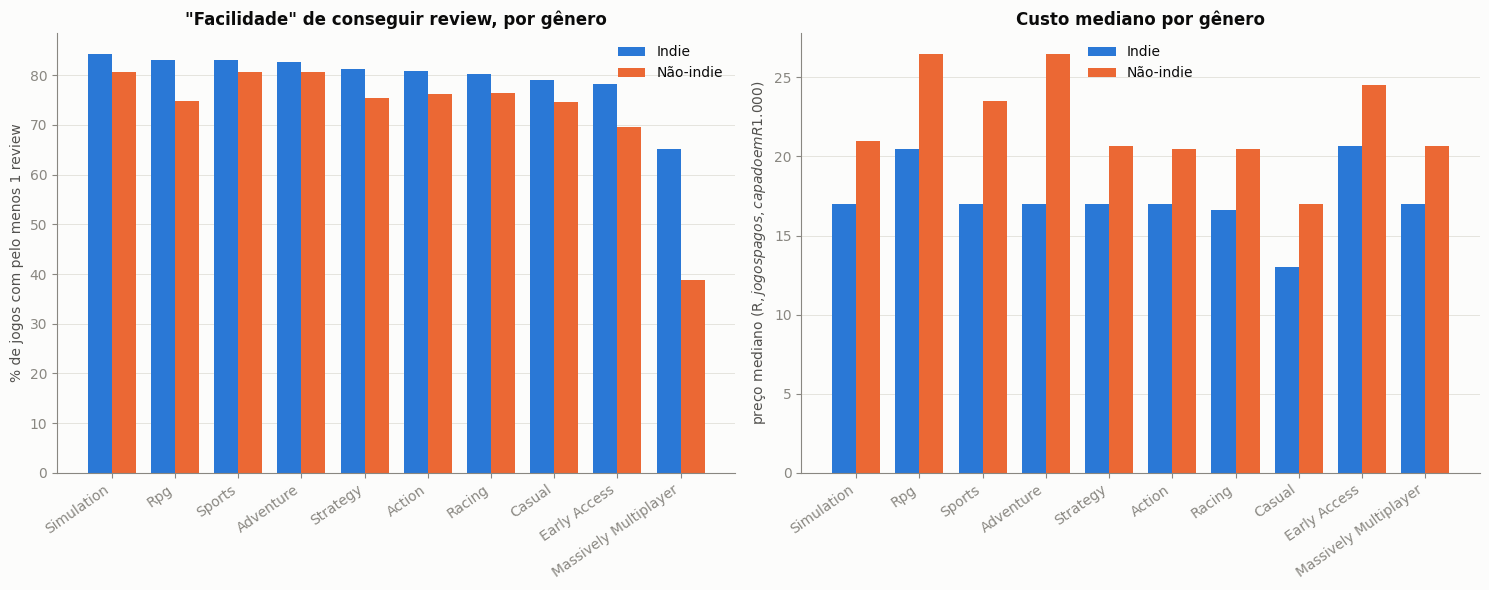

,genero,n_indie,pct_review_indie,preco_mediano_indie,n_naoindie,pct_review_naoindie,preco_mediano_naoindie
6,Simulation,18159,84.3,17.0,7503,80.6,21.0
5,Rpg,15770,83.0,20.5,6109,74.8,26.5
7,Sports,3305,83.0,17.0,1719,80.6,23.5
1,Adventure,35701,82.7,17.0,11346,80.7,26.5
8,Strategy,16961,81.3,17.0,6756,75.5,20.7
0,Action,36316,80.7,17.0,11684,76.1,20.5
4,Racing,2945,80.2,16.6,1301,76.3,20.5
2,Casual,40993,79.0,13.0,12384,74.5,17.0
9,Early Access,8795,78.2,20.7,2535,69.5,24.5
3,Massively Multiplayer,1479,65.1,17.0,1021,38.8,20.7


In [11]:
other_genres = [c for c in genre_cols if c != "genre_indie"]
indie_df, nonindie_df = df[indie_mask], df[~indie_mask]
paid_capped = df[(~df["is_free"]) & (df["price_brl"] <= 1000)]
indie_paid, nonindie_paid = paid_capped[paid_capped["genre_indie"]], paid_capped[~paid_capped["genre_indie"]]

rows = []
for c in other_genres:
    name = c.replace("genre_", "").replace("_", " ").title()
    si, sn = indie_df[indie_df[c]], nonindie_df[nonindie_df[c]]
    spi, spn = indie_paid[indie_paid[c]], nonindie_paid[nonindie_paid[c]]
    rows.append((
        name,
        len(si), (si["reviews_total"] > 0).mean() * 100, spi["price_brl"].median(),
        len(sn), (sn["reviews_total"] > 0).mean() * 100, spn["price_brl"].median(),
    ))
sdf = pd.DataFrame(rows, columns=["genero", "n_indie", "pct_review_indie", "preco_mediano_indie",
                                   "n_naoindie", "pct_review_naoindie", "preco_mediano_naoindie"])
sdf = sdf.sort_values("pct_review_indie", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(sdf))
w = 0.38

axes[0].bar(x - w/2, sdf["pct_review_indie"], width=w, label="Indie", color=BLUE)
axes[0].bar(x + w/2, sdf["pct_review_naoindie"], width=w, label="Não-indie", color=ORANGE)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sdf["genero"], rotation=35, ha="right")
axes[0].set_ylabel("% de jogos com pelo menos 1 review")
axes[0].set_title('"Facilidade" de conseguir review, por gênero')
axes[0].legend(frameon=False)

axes[1].bar(x - w/2, sdf["preco_mediano_indie"], width=w, label="Indie", color=BLUE)
axes[1].bar(x + w/2, sdf["preco_mediano_naoindie"], width=w, label="Não-indie", color=ORANGE)
axes[1].set_xticks(x)
axes[1].set_xticklabels(sdf["genero"], rotation=35, ha="right")
axes[1].set_ylabel("preço mediano (R$, jogos pagos, capado em R$1.000)")
axes[1].set_title("Custo mediano por gênero")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
sdf.round(1)

Pra responder direto a pergunta do professor — **qual gênero é mais fácil de conseguir uma review** — Simulation, RPG, Adventure e Sports formam um grupo bem estável no topo dos dois lados (82-84% entre os indies, 80-81% entre os não-indies): não importa muito se o jogo é indie ou não, esses gêneros tendem a sair do zero. **Massively Multiplayer é disparado o mais difícil em ambos os lados**, mas o achado mais interessante pra mim foi o tamanho da diferença: só 38,8% dos MMOs não-indie têm alguma review, contra 65,1% dos MMOs indie — de longe o maior gap entre indie/não-indie de toda a tabela. Não tenho uma explicação fechada pra isso; minha suspeita é que "MMO não-indie" nessa base inclui bastante joguinho free-to-play de estúdio médio que tentou emplacar um MMO e não conseguiu tração nenhuma, enquanto o rótulo MMO-indie puxa mais pra jogos cooperativos pequenos (tipo survival/sandbox) que têm um público mais garantido. Vale investigar melhor antes de usar isso como explicação em texto.

Sobre **custo por gênero**: olhando a mediana (não a média, pelo motivo já explicado), **não-indie custa mais que indie em todo gênero, sem exceção** — o que faz sentido, produção maior geralmente significa preço maior. RPG e Adventure são os gêneros mais caros do lado não-indie (R\$26,49 de mediana), enquanto Casual é o mais barato dos dois lados (R\$12,99 indie, R\$16,99 não-indie). Achei esse resultado bem mais "limpo" e intuitivo do que os de popularidade — não teve nenhuma inversão estranha pra investigar.

## Análise de Categorias e Características de Jogabilidade

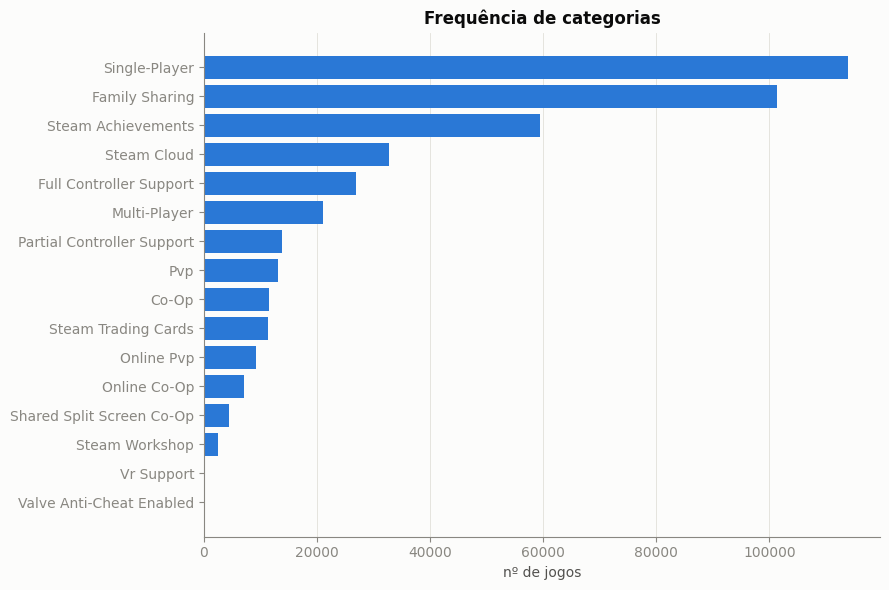

,n,%
Single-Player,113871,96.0
Family Sharing,101360,85.5
Steam Achievements,59465,50.1
Steam Cloud,32740,27.6
Full Controller Support,26947,22.7
Multi-Player,21011,17.7
Partial Controller Support,13899,11.7
Pvp,13095,11.0
Co-Op,11512,9.7
Steam Trading Cards,11311,9.5


In [12]:
cat_cols = [c for c in df.columns if c.startswith("cat_")]
cat_counts = df[cat_cols].sum().sort_values(ascending=False)
cat_counts.index = cat_counts.index.str.replace("cat_", "").str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=BLUE)
ax.set_xlabel("nº de jogos")
ax.set_title("Frequência de categorias")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

cat_pct = (cat_counts / len(df) * 100).round(1)
pd.DataFrame({"n": cat_counts.astype(int), "%": cat_pct})

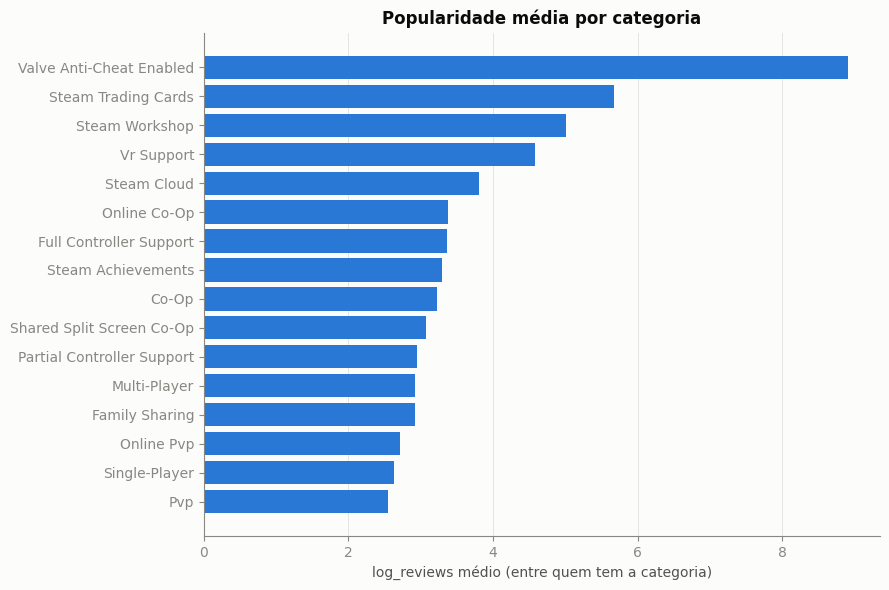

,categoria,n,log_reviews_medio
15,Valve Anti-Cheat Enabled,97,8.906379
9,Steam Trading Cards,11311,5.673814
10,Steam Workshop,2586,5.008633
13,Vr Support,219,4.577016
8,Steam Cloud,32740,3.811264
3,Online Co-Op,7177,3.375100
11,Full Controller Support,26947,3.356725
7,Steam Achievements,59465,3.289403
2,Co-Op,11512,3.218919
4,Shared Split Screen Co-Op,4427,3.066184


In [13]:
rows = []
for c in cat_cols:
    name = c.replace("cat_", "").replace("_", " ").title()
    rows.append((name, df[c].sum(), df.loc[df[c], "log_reviews"].mean()))
cdf = pd.DataFrame(rows, columns=["categoria", "n", "log_reviews_medio"]).sort_values("log_reviews_medio", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ramp_c = plt.cm.Blues(np.linspace(0.9, 0.35, len(cdf)))
ax.barh(cdf["categoria"][::-1], cdf["log_reviews_medio"][::-1], color=BLUE)
ax.set_xlabel("log_reviews médio (entre quem tem a categoria)")
ax.set_title("Popularidade média por categoria")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
cdf

Aqui eu tomaria cuidado antes de tratar isso como causal. `valve_anti-cheat_enabled` aparece no topo, mas só tem 97 jogos com essa flag — e são justamente jogos competitivos já gigantes (CS2, Rust, PUBG, esse tipo de coisa), então é mais um efeito de "quem já é popular o suficiente pra ter cheaters" do que a flag causando popularidade. O mesmo raciocínio vale pra `steam_trading_cards`: cartas colecionáveis são uma feature que a própria Valve libera com mais frequência pra jogos que já têm uma base de jogadores maior, então correlação alta aqui pode estar capturando popularidade prévia, não gerando popularidade nova. Vou levar isso em conta na hora de escolher/interpretar features pro modelo — algumas dessas colunas provavelmente são consequência da popularidade, não causa dela.

### Cartas Colecionáveis — o "Mercado Paralelo"

O professor pediu pra explorar melhor esse ponto: jogos com cartas colecionáveis (Steam Trading Cards) parecem ter muito mais reviews que o resto, o que ele lê como sinal de que cartas ajudam o desenvolvedor a monetizar melhor. Só 9,5% dos jogos da base têm cartas — segue a comparação.

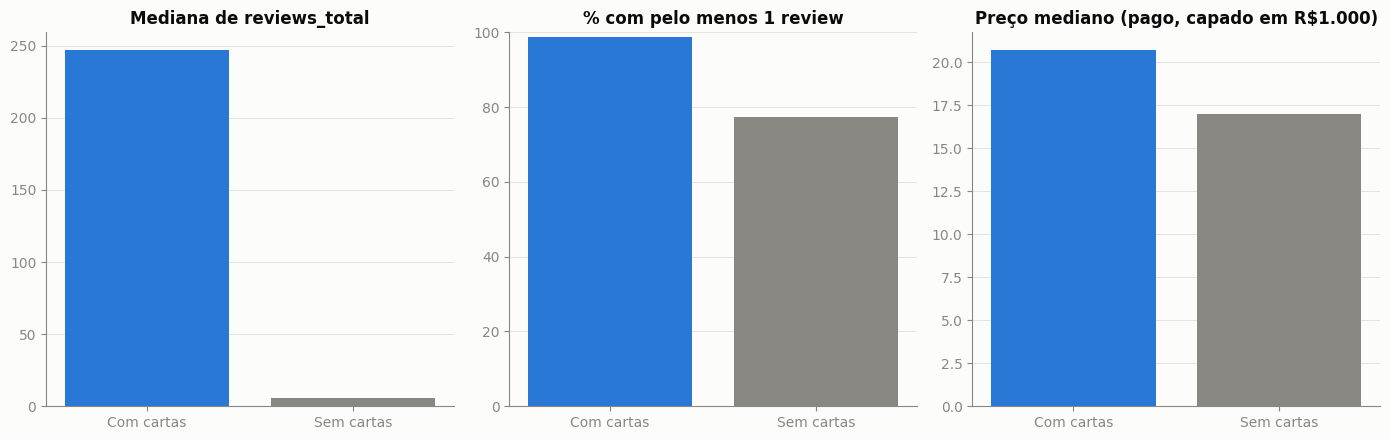

,grupo,n,%,reviews_total_mediana,log_reviews_medio,%_com_review,preco_mediano_pago
0,Com cartas,11311,9.54,247.0,5.67,98.66,20.69
1,Sem cartas,107285,90.46,6.0,2.26,77.32,16.99


In [14]:
cards_mask = df["cat_steam_trading_cards"]
rows = []
for name, mask in [("Com cartas", cards_mask), ("Sem cartas", ~cards_mask)]:
    sub = df[mask]
    sub_paid = sub[(~sub["is_free"]) & (sub["price_brl"] <= 1000)]
    rows.append((
        name, len(sub), len(sub) / len(df) * 100,
        sub["reviews_total"].median(), sub["log_reviews"].mean(),
        (sub["reviews_total"] > 0).mean() * 100,
        sub_paid["price_brl"].median(),
    ))
cards_df = pd.DataFrame(rows, columns=["grupo", "n", "%", "reviews_total_mediana",
                                        "log_reviews_medio", "%_com_review", "preco_mediano_pago"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
cores = [BLUE, MUTED]
axes[0].bar(cards_df["grupo"], cards_df["reviews_total_mediana"], color=cores)
axes[0].set_title("Mediana de reviews_total")
axes[1].bar(cards_df["grupo"], cards_df["%_com_review"], color=cores)
axes[1].set_title("% com pelo menos 1 review")
axes[1].set_ylim(0, 100)
axes[2].bar(cards_df["grupo"], cards_df["preco_mediano_pago"], color=cores)
axes[2].set_title("Preço mediano (pago, capado em R$1.000)")
for ax in axes:
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
cards_df.round(2)

Esse "mercado paralelo" que o professor comentou aparece bem forte nos números. A mediana de `reviews_total` é **41x maior** entre quem tem cartas (247 contra 6), e praticamente todo mundo que tem cartas já saiu do zero (98,7% com pelo menos 1 review, contra 77,3% de quem não tem). Preço mediano também é um pouco mais alto entre quem tem cartas (R\$20,69 contra R\$16,99).

Só que aqui vale a mesma ressalva que já tinha feito acima sobre `valve_anti-cheat_enabled`: a Valve não libera cartas colecionáveis pra qualquer jogo — historicamente é um recurso que ela reserva pra jogos que já têm uma base mínima de jogadores. Então parte grande dessa diferença é seleção (jogo já era popular → ganhou cartas), não cartas causando popularidade do zero. Dito isso, acho que o ponto do professor continua de pé mesmo com essa ressalva: seja qual for a direção da causalidade sobre popularidade, cartas colecionáveis criam um mercado secundário real (Steam Community Market, craft de emblemas/badges) que dá ao desenvolvedor uma fonte de receita adicional em cima da base de jogadores que ele já tem — isso é uma informação relevante sobre monetização, independente de provar causalidade sobre `reviews_total`.

## Análise de Plataformas

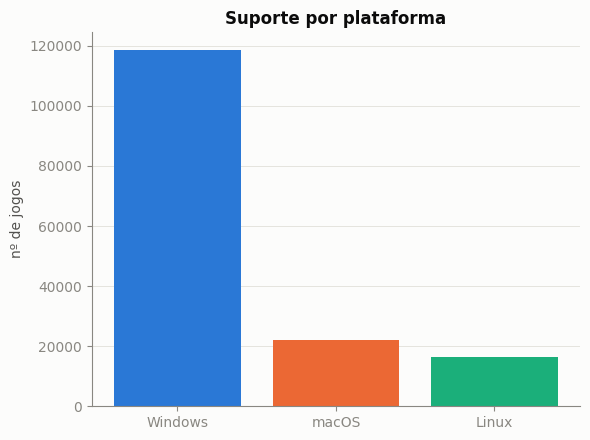

   Windows: 118,571 (100.0%)
       Mac:  21,984 (18.5%)
     Linux:  16,525 (13.9%)


In [15]:
plat_counts = {"Windows": df["windows"].sum(), "macOS": df["mac"].sum(), "Linux": df["linux"].sum()}
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(plat_counts.keys(), plat_counts.values(), color=[BLUE, ORANGE, AQUA])
ax.set_ylabel("nº de jogos")
ax.set_title("Suporte por plataforma")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

for plat in ["windows", "mac", "linux"]:
    n = df[plat].sum()
    print(f"{plat.capitalize():>10}: {n:>7,} ({n/len(df)*100:.1f}%)")

Windows é praticamente universal (100%, como esperado — é a plataforma "default" da Steam). Mac e Linux ficam bem atrás (18,5% e 13,9%), o que acho que reflete custo de portar mais do que falta de demanda. Não fiz o cruzamento com popularidade aqui porque cross-plataforma tende a ser decisão do estúdio (jogos maiores portam mais), então esperaria confundimento forte com o próprio porte do jogo — fica como possível próximo passo, não uma conclusão que eu bateria o martelo agora.

**Limitação (ponto que o professor levantou):** os números acima refletem só suporte nativo declarado pela própria loja da Steam — não contam o Proton, a camada de compatibilidade que deixa muitos jogos Windows-only rodarem normalmente no Linux (é a base do Steam Deck, inclusive). O ProtonDB (protondb.com) registra isso, e cheguei a testar a API não-documentada do site pra ver se dava pra puxar: dá, mas seriam ~118 mil consultas novas — uma coleta de mais de um dia rodando — e não achei que valesse gastar esse tempo nessa etapa do trabalho. Fica registrado como limitação em vez de conclusão: a coluna `linux` aqui provavelmente subestima quantos jogos da base são, na prática, jogáveis no Linux.

## Análise Temporal

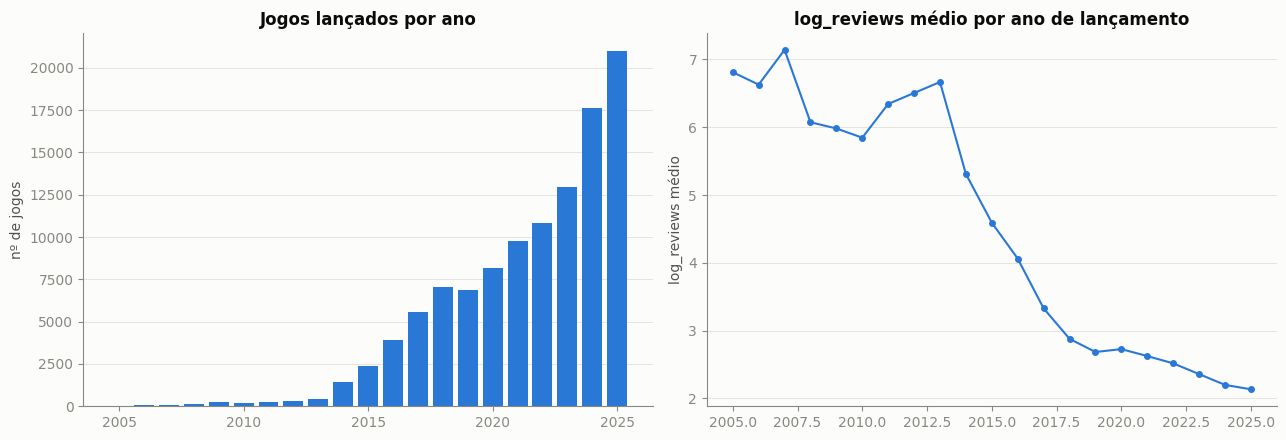

In [16]:
df_years = df[df["release_year"].between(2005, 2025)].copy()
year_stats = df_years.groupby("release_year").agg(n_jogos=("appid", "count"), log_reviews_medio=("log_reviews", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(year_stats.index, year_stats["n_jogos"], color=BLUE)
axes[0].set_title("Jogos lançados por ano")
axes[0].set_ylabel("nº de jogos")

axes[1].plot(year_stats.index, year_stats["log_reviews_medio"], color=BLUE, marker="o", markersize=4)
axes[1].set_title("log_reviews médio por ano de lançamento")
axes[1].set_ylabel("log_reviews médio")

for ax in axes:
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Dois efeitos bem claros aqui. Primeiro, o número de lançamentos por ano cresce muito ao longo do tempo — reflexo direto da Steam ter aberto o catálogo (Steam Direct, 2017) pra qualquer desenvolvedor publicar. Segundo, e mais importante pra modelagem: `log_reviews` médio **cai** conforme o ano de lançamento é mais recente. Isso não significa que jogos novos são piores — é um efeito de janela de tempo: um jogo lançado em 2012 teve mais de uma década pra acumular reviews, um lançado em 2025 teve meses. `release_year` sozinho carrega esse viés de "tempo desde o lançamento", então acho que faz sentido considerar isso explicitamente no modelo (por exemplo, como uma feature de "dias desde o lançamento até a data da coleta" em vez de simplesmente o ano).

## Análise de Sentimento do Público (`review_score_desc`)

Vale um comentário importante antes do gráfico: **"No user reviews" mistura duas populações diferentes.** Jogos com zero reviews de verdade caem nessa categoria, mas jogos com pouquíssimas reviews (a Steam não calcula um "review_score" textual confiável abaixo de um certo volume) também caem no mesmo rótulo. Ou seja, "sem sinal" e "sinal fraco" ficam indistinguíveis nessa coluna — bom saber disso antes de usar `review_score_desc` como target de classificação.

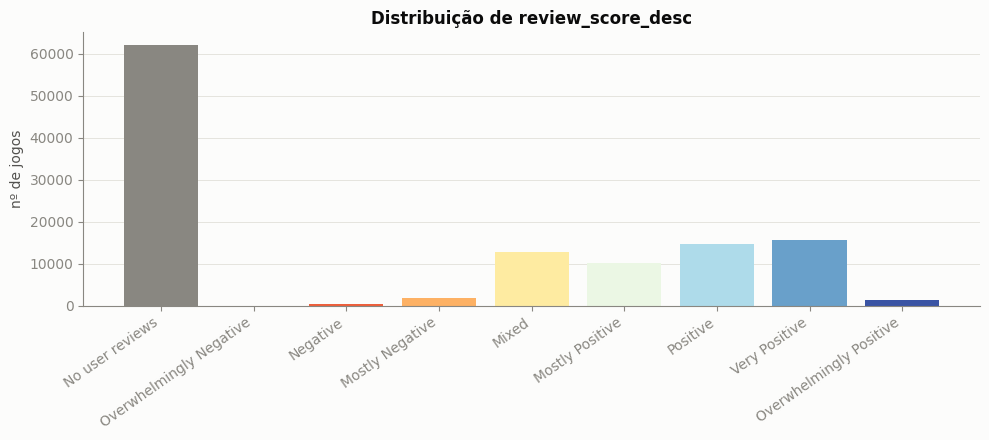

,n,%
review_score_desc,,
No user reviews,61986,52.3
Overwhelmingly Negative,5,0.0
Negative,339,0.3
Mostly Negative,1811,1.5
Mixed,12804,10.8
Mostly Positive,10098,8.5
Positive,14581,12.3
Very Positive,15651,13.2
Overwhelmingly Positive,1321,1.1


In [17]:
order = ["No user reviews", "Overwhelmingly Negative", "Very Negative", "Negative", "Mostly Negative",
          "Mixed", "Mostly Positive", "Positive", "Very Positive", "Overwhelmingly Positive"]
counts = df["review_score_desc"].value_counts().reindex(order).dropna()

# cores na ordem: cinza pro "sem review", diverging vermelho->azul pro resto (negativo->positivo)
n_scale = len(counts) - 1
diverging = plt.cm.RdYlBu(np.linspace(0.05, 0.95, n_scale))
colors = [MUTED] + list(diverging)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel("nº de jogos")
ax.set_title("Distribuição de review_score_desc")
plt.xticks(rotation=35, ha="right")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

pct = (counts / len(df) * 100).round(1)
pd.DataFrame({"n": counts.astype(int), "%": pct})

### `review_ratio` — taxa de aprovação entre quem já tem review

Olhando só pros jogos que já têm pelo menos 1 review (pra não misturar com o "sem sinal" de novo).

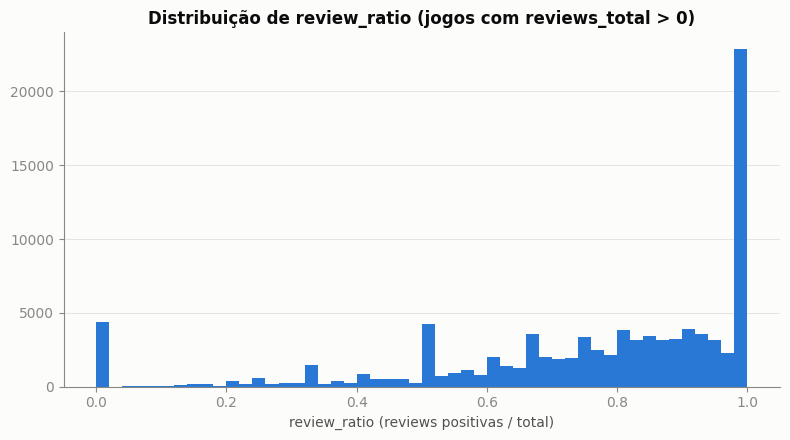

count    94117.000000
mean         0.757618
std          0.259214
min          0.000000
25%          0.647059
50%          0.833333
75%          0.972255
max          1.000000
Name: review_ratio, dtype: float64


In [18]:
df_com_rev = df[df["reviews_total"] > 0].copy()
df_com_rev["review_ratio"] = df_com_rev["reviews_positive"] / df_com_rev["reviews_total"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_com_rev["review_ratio"], bins=50, color=BLUE)
ax.set_xlabel("review_ratio (reviews positivas / total)")
ax.set_title("Distribuição de review_ratio (jogos com reviews_total > 0)")
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(df_com_rev["review_ratio"].describe())

A distribuição é bem concentrada em valores altos (mediana bem acima de 0,5) — a maioria dos jogos que recebe reviews recebe majoritariamente reviews positivas. Isso é consistente com o que já se sabe sobre a Steam: quem compra um jogo tende a já ter alguma triagem prévia (trailers, reviews de outros, preço), então quem chega a jogar e avaliar tende a gostar mais do que odiar, em média.

## Análise de Correlações

Uso correlação de Pearson pra ter uma primeira ideia de quais variáveis se relacionam mais com `log_reviews` — sem esquecer que correlação não é causalidade, principalmente nas colunas binárias de categoria (comentei isso acima).

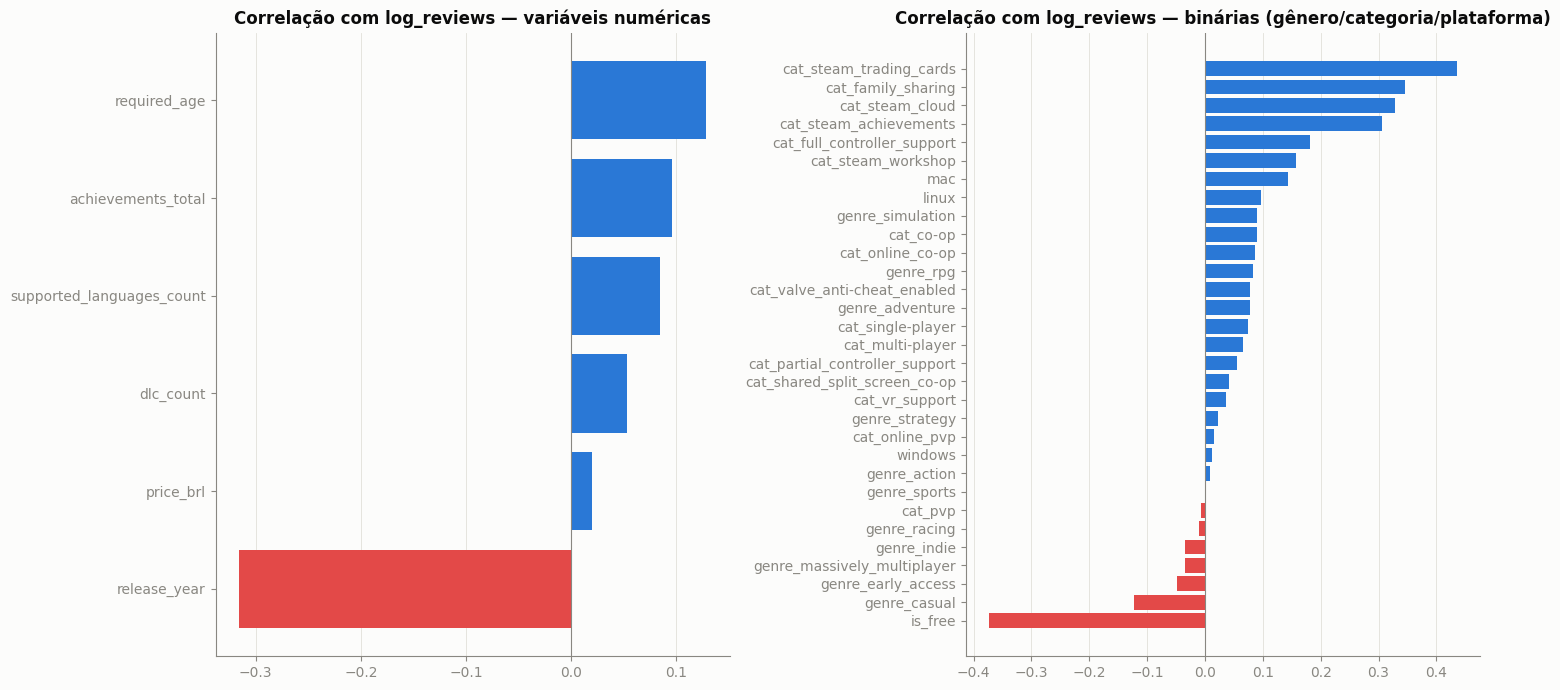

In [19]:
num_cols = ["price_brl", "achievements_total", "supported_languages_count", "dlc_count", "required_age", "release_year"]
corr_num = df[num_cols + ["log_reviews"]].corr()["log_reviews"].drop("log_reviews").sort_values()

bool_cols = ["is_free", "windows", "mac", "linux"] + genre_cols + cat_cols
corr_bool = df[bool_cols + ["log_reviews"]].corr()["log_reviews"].drop("log_reviews").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

colors_num = [RED if v < 0 else BLUE for v in corr_num.values]
axes[0].barh(corr_num.index, corr_num.values, color=colors_num)
axes[0].set_title("Correlação com log_reviews — variáveis numéricas")
axes[0].axvline(0, color=MUTED, linewidth=0.8)

colors_bool = [RED if v < 0 else BLUE for v in corr_bool.values]
axes[1].barh(corr_bool.index, corr_bool.values, color=colors_bool)
axes[1].set_title("Correlação com log_reviews — binárias (gênero/categoria/plataforma)")
axes[1].axvline(0, color=MUTED, linewidth=0.8)

for ax in axes:
    ax.grid(axis="x", linewidth=0.6)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

O que mais chama atenção pra mim aqui é `is_free`: correlação negativa (-0,37), ou seja, jogos gratuitos tendem a ter **menos** reviews em média do que jogos pagos nesse dataset. Isso é meio contra-intuitivo — eu esperaria o contrário, já que jogos F2P costumam ter base de jogadores maior. Fui conferir na mão pra não sair afirmando errado: a mediana de `reviews_total` entre jogos gratuitos é **0** (mais da metade não tem nenhuma review), contra 12 entre os pagos. Acho que a explicação é de composição: a categoria "grátis" mistura os poucos F2P gigantes (CS2 entre eles) com uma quantidade enorme de joguinhos pequenos, ferramentas e "asset flips" publicados de graça — e esses últimos dominam a média porque são muitos. Vale investigar melhor antes de tirar conclusão definitiva, mas por ora essa é minha leitura.

`release_year` tem a correlação negativa mais forte entre as numéricas (-0,32), pelo motivo que já expliquei na seção temporal (viés de tempo de acúmulo). Achievements, idiomas suportados e DLC têm correlação positiva mas fraca — indicam jogos "mais robustos"/com mais investimento, mas sozinhos não explicam muito.

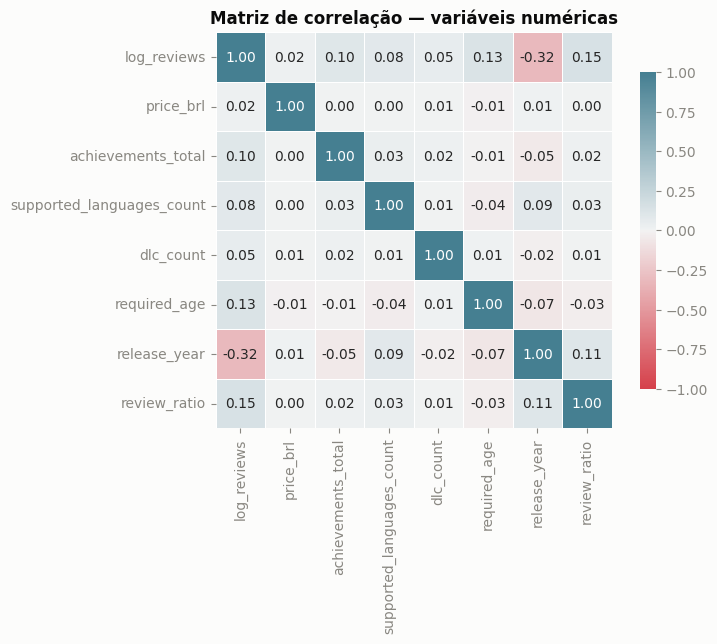

In [20]:
num_cols_hm = ["log_reviews", "price_brl", "achievements_total", "supported_languages_count",
               "dlc_count", "required_age", "release_year", "review_ratio"]
hm_df = df.copy()
hm_df["review_ratio"] = hm_df["reviews_positive"] / hm_df["reviews_total"].replace(0, np.nan)
corr_matrix = hm_df[num_cols_hm].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
cmap = sns.diverging_palette(10, 220, s=70, l=50, as_cmap=True)  # vermelho <-> azul, cinza no meio
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.show()

## Síntese e Recomendações para a Modelagem

### Principais achados

| Aspecto | Achado |
|---|---|
| Cobertura da coleta | V2 (`/appreviews`) resolve o problema de `reviews_total` faltante da V1 — só 0,3% dos apps ficam sem esse dado, contra 86,7% na V1 |
| Escopo da coleta | A base nunca teve DLC/soundtrack/software — só jogos, por comportamento padrão do `GetAppList`. `steam-dados-v2.csv` e `steam-jogos-v2.csv` são idênticos hoje |
| Curadoria | Dos 171.769 apps coletados, ~31% são descartados na limpeza (principalmente por falta de data de lançamento parseável e jogos pagos sem preço). Sobram 118.596 jogos |
| Alvo | `reviews_total` extremamente assimétrico; uso `log1p` na maior parte das análises. 20,6% dos jogos não têm nenhuma review |
| Gênero | Indie se sobrepõe a 59-78% de cada outro gênero — não funciona como gênero de conteúdo, e sim como rótulo de modelo de publicação; por isso viro a análise em torno dele como corte mestre. Simulation/RPG/Adventure/Sports são os gêneros "mais fáceis" de sair do zero (80%+ com pelo menos 1 review, nos dois lados); Massively Multiplayer é disparado o mais difícil, principalmente entre não-indies (38,8% vs. 65,1% entre indies) |
| Custo por gênero | Olhando a mediana, não-indie custa mais que indie em todo gênero sem exceção; RPG/Adventure são os mais caros do lado não-indie, Casual é o mais barato dos dois lados |
| Categorias de feature | Cartas colecionáveis (9,5% dos jogos) têm mediana de `reviews_total` 41x maior que o resto — mistura de seleção (Valve libera cartas pra quem já é popular) com efeito real de mercado paralelo (Steam Community Market). Mesma ressalva causal vale pra `valve_anti-cheat_enabled` |
| Tempo | `release_year` correlaciona negativamente com `log_reviews` por viés de janela de acúmulo, não porque jogos novos são "piores" |
| Gratuito vs. pago | Contra-intuitivamente, jogos grátis têm mediana de reviews menor que pagos — efeito de composição (muitos F2P pequenos/asset flips ao lado de poucos gigantes) |
| Outliers | `price_brl` tem valores que parecem erro de coleta/conversão (precisa tratamento); `achievements_total` e `dlc_count` têm outliers legítimos (LOGistICAL, Trainz) |

### Recomendações pra modelagem

- **Target**: `log_reviews` (regressão) e/ou faixas de popularidade (classificação multiclasse) como alternativa — dado o formato de cauda longa, acho a segunda opção pelo menos vale comparar com a primeira.
- **Colunas a excluir por vazamento de dado**: `reviews_positive`, `reviews_negative` (usadas pra derivar o target), `review_ratio` (derivada delas), `log_reviews` (é o próprio target), `appid`/`name` (identificadores).
- **Excluir `metacritic_score`**: ~96,6% faltante, viés de seleção forte.
- **Tratar outliers de `price_brl`** antes de escalar (capar ou investigar os 189 casos > R\$1.000).
- Colunas binárias (`genre_*`, `cat_*`, plataformas, `is_free`) já estão em {0,1}, não devem ser reescaladas; colunas numéricas contínuas sim (padronização ou min-max).
- Considerar transformar `release_year` em "tempo desde o lançamento" pra isolar o viés temporal de acúmulo de reviews.
- Cuidado interpretativo com colunas de categoria que podem ser consequência (não causa) de popularidade — não inviabiliza usá-las como feature preditiva, mas inviabiliza usá-las como explicação causal no texto do TCC.
- Considerar `genre_indie` como uma feature à parte (corte estrutural), em vez de tratar ela igual às outras dummies de gênero — o padrão de sobreposição que vi aqui sugere que ela captura algo diferente (modelo de publicação) do que os outros gêneros (conteúdo).

## O que isso muda no TCC

Juntando tudo, a lista do que preciso mexer no texto:

1. **Seção 3.1/Tabela 3.2** ainda descreve a coleta V1 (86,7% de `reviews_total` faltante). Preciso reescrever pra descrever a V2 (`/appreviews`, 0,3% faltante) — esse ponto já estava mapeado antes desse notebook.
2. **Nova**: preciso deixar claro na metodologia que a coleta é (e sempre foi) só de jogos — não é uma escolha de filtro que eu documentei antes, é consequência do endpoint de listagem usado. Vou descrever isso explicitamente em vez de deixar implícito.
3. **Nova**: preciso adicionar uma descrição da etapa de curadoria/limpeza (a queda de 171.769 → 118.596 apps) — hoje o TCC não fala nada sobre esse passo, e é uma fatia grande demais dos dados pra não justificar no texto.
4. **Nova**: registrar a ressalva de que `review_score_desc` mistura "sem review" com "poucas reviews" sob o mesmo rótulo, caso eu use essa coluna como alternativa de target mais pra frente.
5. Atualizar a contagem final do dataset de modelagem para 118.596 jogos (o número que estava registrado antes, 118.537, vinha de uma execução com um bug de caminho de arquivo que já corrigi).

Professor, um dos pontos que eu gostaria de discutir com o senhor é justamente o item 2 — não tinha me dado conta antes que a nossa base nunca incluiu DLC/software, e queria confirmar com o senhor se isso muda alguma coisa na forma como enquadramos o problema de pesquisa (acho que não, já que o objetivo sempre foi popularidade de *jogos*, mas prefiro confirmar).